In [198]:
# https://grouplens.org/datasets/movielens/100k/
# https://www.kaggle.com/code/thehoang56738/contentbase-filtering

import numpy as np
import pandas as pd

item_cols = ["movie_id", "movie_name", "release_date", "???", "url"]
newcols = [f"col{i}" for i in range(24 - len(item_cols))]
movie_items = pd.read_csv('ml-100k/u.item', sep='|', names=item_cols + newcols, encoding='latin-1', parse_dates = [2])
movie_items["movie_name"] = ["".join(filter(str.isalnum, s)) for s in movie_items["movie_name"]]
movie_items = movie_items[["movie_id", "movie_name"]]
movie_items[movie_items["movie_name"].str.contains("Batman")]
#movie_items

,movie_id,movie_name
28,29,BatmanForever1995
230,231,BatmanReturns1992
253,254,BatmanRobin1997
402,403,Batman1989


In [147]:
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']

# u.data instead of ua.base for alla datapoints.
data = pd.read_csv('ml-100k/u.data', sep='\t', names=r_cols, encoding='latin-1')
data.drop('unix_timestamp', inplace=True, axis=1)

In [148]:
genre = pd.read_csv('ml-100k/u.genre', sep='|', names=r_cols, encoding='latin-1')
info = pd.read_csv('ml-100k/u.info', sep=' ', names=r_cols, encoding='latin-1')
info.tail()

,user_id,movie_id,rating,unix_timestamp
0,943,users,NaN,NaN
1,1682,items,NaN,NaN
2,100000,ratings,NaN,NaN


<Axes: >

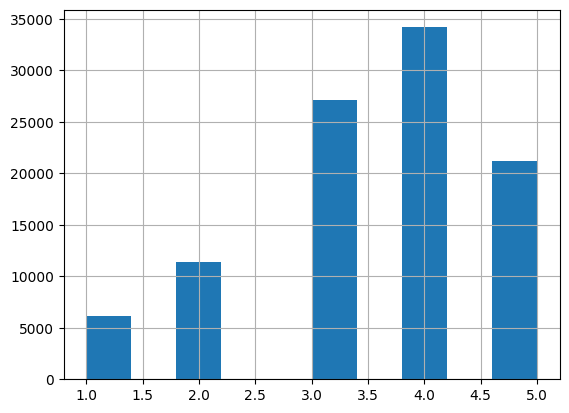

In [149]:
data['rating'].hist()

In [150]:
data.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [151]:
print('   len:', len(data))
print(' #user:', len(np.unique(data['user_id'])))
print('#movie:', len(np.unique(data['movie_id'])))
print('rating:', np.unique(data['rating']))

   len: 100000
 #user: 943
#movie: 1682
rating: [1 2 3 4 5]


In [76]:
# Dataset which containts movie ratigns from 1 to 5. We keep only positive ratings, defined to be ratings of 3 or more ( we subtract 2 from all ratings and set the negative ones to 0).
# The context of each rating is the other movies rated by the same user. After removing users who rated fewer than 20 movies and movies that were rated fewer than 50 times.
# We end up with 777 users, and 516 moveis; 5% sparsity.

In [152]:
data['movie_id'].value_counts().head(100)

movie_id
50     583
258    509
100    508
181    507
294    485
      ... 
8      219
678    219
427    219
95     219
322    218
Name: count, Length: 100, dtype: int64

In [153]:
data['user_id'].value_counts().head(100)



user_id
405    737
655    685
13     636
450    540
276    518
      ... 
506    242
932    241
886    240
798    239
244    238
Name: count, Length: 100, dtype: int64

In [154]:
# Vocabulary size
V = 600
data['binary_rating'] = [int(max(0, min(rating - 2, 1))) for rating in data['rating']]

# Only take the V movies with most reviews
movie_counts = data['movie_id'].value_counts()
movies_to_keep = data['movie_id'].value_counts().head(V).index

# Only keep users with multiple reviews
user_counts = data['user_id'].value_counts()
users_to_keep = user_counts[user_counts >= 2].index

print(len(data))
data = data[data['movie_id'].isin(movies_to_keep)]
print(len(data))
data = data[data['movie_id'].isin(movies_to_keep)]
print(len(data))
data

100000
83565
83565


,user_id,movie_id,rating,binary_rating
0,196,242,3,1
1,186,302,3,1
3,244,51,2,0
4,166,346,1,0
5,298,474,4,1
...,...,...,...,...
99993,913,209,2,0
99995,880,476,3,1
99996,716,204,5,1
99998,13,225,2,0


In [155]:
print('After filter')
print('   len:', len(data))
print(' #user:', len(np.unique(data['user_id'])))
print('#movie:', len(np.unique(data['movie_id'])))
print('rating:', np.unique(data['rating']))
print('binary_rating:', np.sum(data['binary_rating']==0), np.sum(data['binary_rating']==1))

After filter
   len: 83565
 #user: 943
#movie: 600
rating: [1 2 3 4 5]
binary_rating: 12233 71332


<Axes: >

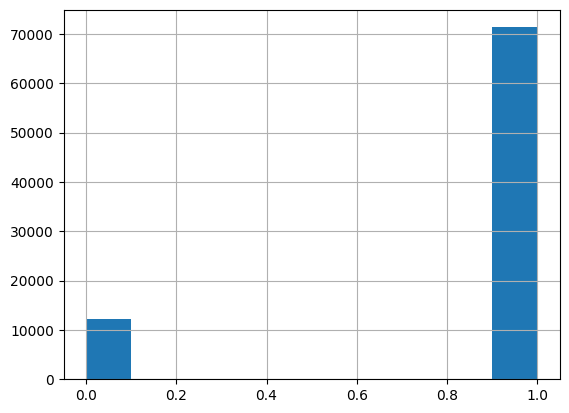

In [156]:
data['binary_rating'].hist()

w is the center "word", in this case a movie_id and v the context movie. 'x' denotes if its a positive or negative word pair. The way we define x is as follows: If a movie has positive rating (1) and the context word is negative (0) we get x = 0,  if bot are 1 we set x = 1, if the center word is negative(0) we skip it.


In [157]:
data_sub = data.sample(len(data)).groupby('user_id').head(25).sort_values("user_id")
data_sub
len(data), len(data_sub)

(83565, 22705)

In [158]:
print('After subsetting')
print('   len:', len(data_sub))
print(' #user:', len(np.unique(data_sub['user_id'])))
print('#movie:', len(np.unique(data_sub['movie_id'])))
print('rating:', np.unique(data_sub['rating']))
print('binary_rating:', np.sum(data_sub['binary_rating']==0), np.sum(data_sub['binary_rating']==1))

After subsetting
   len: 22705
 #user: 943
#movie: 600
rating: [1 2 3 4 5]
binary_rating: 3354 19351


In [159]:
import tqdm
import pandas as pd
import json
import itertools
import numpy as np
from collections import Counter

def generate_word_pairs_with_negative_sampling(data, num_negative_samples=1):
    word_pairs = []
    
    # Filter out negatively rated movies -- TODO: is this reasonable?
    #positive_data = data[data['rating'] == 1]
    
    # -- negative sampling: empirical distribution ** 3/4
    movie_counts = Counter(data['movie_id'])
    total_count = sum(movie_counts.values())
    movie_distribution = {movie: (count/total_count) ** 0.75 for movie, count in movie_counts.items()}
    total_distribution = sum(movie_distribution.values())
    movie_distribution = {movie: freq/total_distribution for movie, freq in movie_distribution.items()}
    
    movies = list(movie_distribution.keys())
    probabilities = list(movie_distribution.values())
    
    for user_id in tqdm.tqdm(data['user_id'].unique()):
        # Loop over both positively and negatively rated movies for each user
        for rating in [1, 0]:
            user_movies = data[data['user_id'] == user_id]
            user_movies = user_movies[user_movies['binary_rating'] == rating]
            user_movies = user_movies['movie_id'].tolist()
            
            # --- extract positive pairs ---
            for movie1, movie2 in itertools.combinations(user_movies, 2):
                movie1 = movie_items_dict[movie1]
                movie2 = movie_items_dict[movie2]
                word_pairs.append({
                    "v": str(movie1),
                    "w": str(movie2),
                    "x": 1
                })
                word_pairs.append({
                    "v": str(movie2),
                    "w": str(movie1),
                    "x": 1
                })
                
                # --- negative samples for each positive pair ---
                for _ in range(num_negative_samples):
                    negative_movie = np.random.choice(movies, p=probabilities)
                    negative_movie = movie_items_dict[negative_movie]
                    
                    # Positive and negative samples are not exclusive
                    #while negative_movie in user_movies:
                    #    negative_movie = np.random.choice(movies, p=probabilities)
                    
                    word_pairs.append({
                        "v": str(movie1),
                        "w": str(negative_movie),
                        "x": 0
                    })
                    word_pairs.append({
                        "v": str(movie2),
                        "w": str(negative_movie),
                        "x": 0
                    })
    
    return word_pairs


word_pairs = generate_word_pairs_with_negative_sampling(data_sub)

all_movies = set()
for pair in word_pairs:
    all_movies.add(pair['v'])
    all_movies.add(pair['w'])

vocabulary = {movie: idx for idx, movie in enumerate(sorted(all_movies))}

json_data = {
    "vocabulary": vocabulary,
    "data": word_pairs
}

with open('movielens_with_ns.json', 'w') as f:
    json.dump(json_data, f, indent=0)


100%|██████████| 943/943 [00:09<00:00, 98.96it/s] 


In [13]:
25 * 84

2100

In [160]:
import sys
sys.getsizeof(json_data['data'])

6675480

In [161]:
len(json_data['data'])

816116

In [133]:
pd.DataFrame(json_data['data'])

,v,w,x
0,242,393,1
1,393,242,1
2,242,202,0
3,393,202,0
4,242,381,1
...,...,...,...
9097371,294,120,0
9097372,245,515,1
9097373,515,245,1
9097374,245,8,0
